# 👩‍💻 Use an LSTM for Time Series Forecasting

## 📋 Overview
In this lab, you'll build and implement a Long Short-Term Memory (LSTM) neural network for time series forecasting. Working with synthetic sine wave data, you'll learn how to prepare sequential data, construct an LSTM model in PyTorch, train it effectively, and evaluate its predictions. By the end of this lab, you'll have created a model that can predict future values in a time series pattern - a technique widely used in stock market prediction, weather forecasting, and demand planning.

## 🎯 Learning Outcomes
By the end of this lab, you will be able to:

- Transform raw data into sequence format for LSTM processing
- Implement and configure an LSTM model architecture in PyTorch
- Train an LSTM model with appropriate hyperparameters
- Evaluate and visualize time series predictions against actual values

## 🚀 Starting Point
Access the starter code by creating a new Python file or using a Jupyter notebook.

Required tools/setup:

- PyTorch
- NumPy
- Matplotlib
- Python 3.6 or later

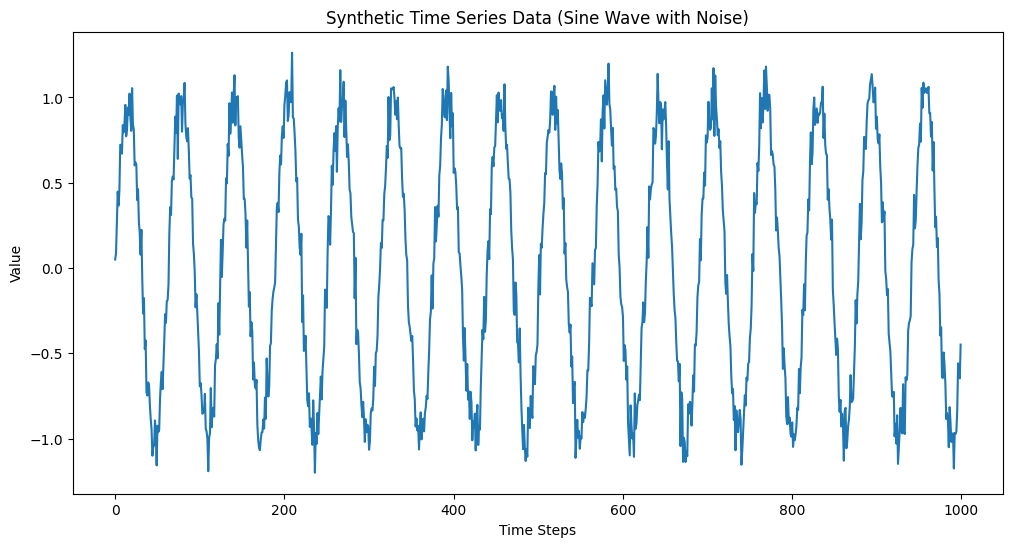

In [1]:
# Starter code: Imports and data generation
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

# Generate synthetic time series data (sine wave)
np.random.seed(42)
time_steps = np.linspace(0, 100, 1000)
data = np.sin(time_steps) + np.random.normal(0, 0.1, size=len(time_steps))

# Plot the data to visualize
plt.figure(figsize=(12, 6))
plt.plot(data)
plt.title("Synthetic Time Series Data (Sine Wave with Noise)")
plt.xlabel("Time Steps")
plt.ylabel("Value")
plt.show()

## Task 1: Prepare Sequential Data
**Context:** Time series forecasting requires data to be formatted as sequences with input windows and target values. For LSTMs, we need to structure our data as sequences of past observations to predict future values.

**Steps:**

1. Create a function to transform the time series data into sequences

    - Use the `np.array` function to store your sequences
    - Consider how a sliding window approach works with parameters like `seq_length`
    - What's the appropriate target for each sequence? (Think about forecasting one step ahead)

2. Split the data into training and testing sets

    - Use `torch.tensor()` to convert numpy arrays to PyTorch tensors
    - Remember to set the correct data type (`dtype=torch.float32`)

3. Create a custom dataset class for better data handling

    - Implement the `__len__` and `__getitem__` methods required by PyTorch's Dataset
    - Format each sample as a sequence-target pair

In [2]:
# Task 1: Prepare Sequential Data
# def create_sequences(data, seq_length):
#     """
#     Transform a time series into sequences for LSTM processing
#     """
#     # Your code here
    
# # Set sequence length (window size for prediction)
# seq_length = 20

# # Create sequences from time series data
# # Your code here

# # Split data into training and testing sets (80/20 split)
# # Your code here

# # Create PyTorch dataset
# class TimeSeriesDataset(Dataset):
#     # Your code here
    
# # Create data loaders
# # Your code here

def create_sequences(data, seq_length):
    """
    Transform a time series into sequences for LSTM processing
    """
    sequences = []
    targets = []
    for i in range(len(data) - seq_length):
        seq = data[i:i+seq_length]
        target = data[i+seq_length]
        sequences.append(seq)
        targets.append(target)
    return np.array(sequences), np.array(targets)

# Set sequence length (window size for prediction)
seq_length = 20

# Create sequences from time series data
X, y = create_sequences(data, seq_length)

# Split data into training and testing sets (80/20 split)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(2)  # Add feature dimension
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(2)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Create PyTorch dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create data loaders
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

**💡 Tip:** When creating sequences, make sure your target value is positioned correctly relative to each input sequence (e.g., the next value after the sequence ends for one-step-ahead prediction).

## Task 2: Design the LSTM Model
**Context:** LSTMs are particularly effective for time-series because they can remember patterns over long sequences. You'll build a model that processes sequence data and outputs predictions.

**Steps:**

1. Create an LSTM class inheriting from `nn.Module`

    - Consider the appropriate input size, hidden size, and number of layers
    - Use `nn.LSTM` for the recurrent layers
    - Use `nn.Linear` for the output layer

2. Initialize the model parameters

    - Set the size of hidden states
    - Configure the number of LSTM layers
    - Set the output dimension based on your prediction task

3. Implement the forward pass

    - Initialize hidden states using torch.zeros
    - Pass input through the LSTM layer with proper hidden state handling
    - Extract the relevant output and pass through final linear layer

In [3]:
# Task 2: Design the LSTM Model
# class LSTMModel(nn.Module):
#     def __init__(self, input_size, hidden_size, num_layers, output_size):
#         """
#         Initialize LSTM model architecture
#         """
#         # Your code here
        
#     def forward(self, x):
#         """
#         Forward pass through the network
#         """
#         # Your code here
        
# # Initialize the model with appropriate parameters
# # Your code here

class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        """
        Initialize LSTM model architecture
        """
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Output layer
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        """
        Forward pass through the network
        """
        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Get output from the last time step
        out = self.fc(out[:, -1, :])
        return out

# Initialize the model with appropriate parameters
input_size = 1  # Single feature (univariate time series)
hidden_size = 64  # Size of LSTM hidden units
num_layers = 2  # Number of stacked LSTM layers
output_size = 1  # Single output (next value prediction)

model = LSTMModel(input_size, hidden_size, num_layers, output_size)

**💡 Tip:** For time series prediction, your input_size is typically 1 (for univariate data) and output_size is 1 (for single-step prediction), but hidden_size can be larger (e.g., 50-100) to capture complex patterns.

## Task 3: Train the LSTM Model
**Context:** Training an LSTM involves feeding sequences, calculating loss, and updating weights through backpropagation. The process requires careful monitoring to ensure the model is learning effectively.

**Steps:**

1. Define loss function and optimizer

    - Use `nn.MSELoss()` for regression tasks
    - Configure `optim.Adam` with an appropriate learning rate

2. Create a training loop

    - Iterate through your training data in batches
    - Zero gradients with `optimizer.zero_grad()`
    - Compute model outputs and loss
    - Call `loss.backward()` and `optimizer.step()` to update weights

3. Track and display training progress

    - Store loss values for plotting
    - Print progress at regular intervals

Epoch [10/100], Loss: 0.0136
Epoch [20/100], Loss: 0.0129
Epoch [30/100], Loss: 0.0127
Epoch [40/100], Loss: 0.0119
Epoch [50/100], Loss: 0.0121
Epoch [60/100], Loss: 0.0120
Epoch [70/100], Loss: 0.0111
Epoch [80/100], Loss: 0.0132
Epoch [90/100], Loss: 0.0113
Epoch [100/100], Loss: 0.0118


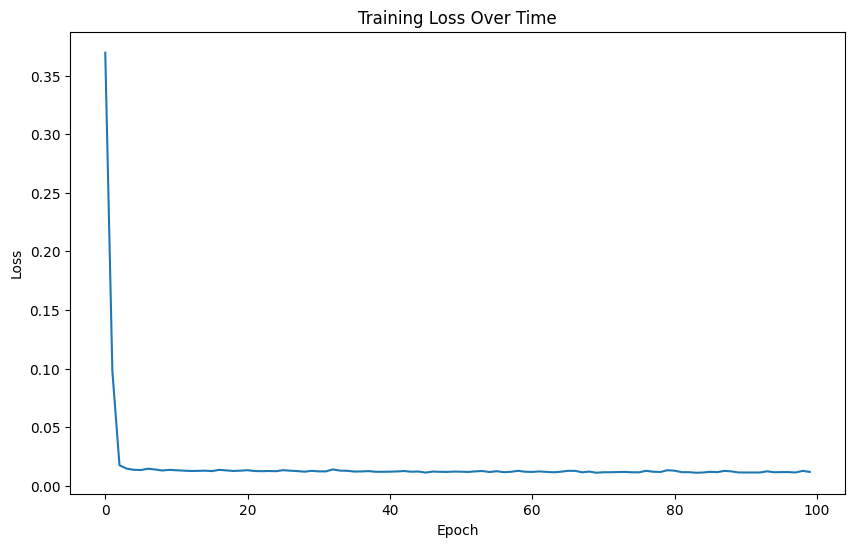

In [4]:
# Task 3: Train the LSTM Model

# # Define loss function and optimizer
# # Your code here

# # Set training parameters
# num_epochs = 100
# batch_size = 32

# # Initialize lists to store metrics
# train_losses = []

# # Training loop
# # Your code here

# # Plot training loss
# plt.figure(figsize=(10, 6))
# plt.plot(train_losses)
# plt.title('Training Loss Over Time')
# plt.xlabel('Epoch')
# plt.ylabel('Loss')
# plt.show()


# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Set training parameters
num_epochs = 100
batch_size = 32

# Initialize lists to store metrics
train_losses = []

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), targets)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    # Track training progress
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

**💡 Tip:** Consider implementing early stopping by monitoring validation loss to prevent overfitting, especially with longer training runs.

## Task 4: Evaluate and Visualize Predictions
**Context:** After training, you need to evaluate how well your model can predict future values and visualize the results to understand its performance.

**Steps:**

1. Set the model to evaluation mode

    - Use `model.eval()` to disable dropout and other training-specific behaviors
    - Use `torch.no_grad()` context manager to disable gradient calculation

2. Generate predictions on test data

    - Feed test sequences through the model
    - Convert predictions back to numpy arrays for visualization

3. Create visualization comparing predictions with actual values

    - Use `matplotlib.pyplot` to plot actual vs. predicted values
    - Add appropriate labels and title to clarify the visualization

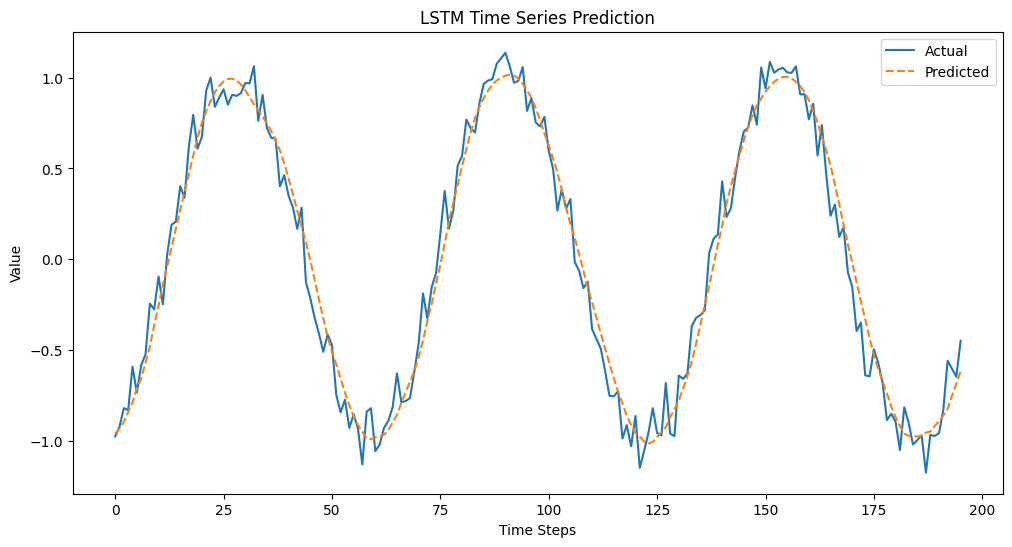

Test MSE: 0.0139
Test MAE: 0.0950


In [5]:
# # Task 4: Evaluate and Visualize Predictions

# # Set model to evaluation mode
# # Your code here

# # Generate predictions
# # Your code here

# # Convert tensors to numpy arrays
# # Your code here

# # Create visualization
# plt.figure(figsize=(12, 6))
# # Your code here
# plt.title('LSTM Time Series Prediction')
# plt.xlabel('Time Steps')
# plt.ylabel('Value')
# plt.legend()
# plt.show()

# # Calculate error metrics
# # Your code here

# Task 4: Evaluate and Visualize Predictions

# Set model to evaluation mode
model.eval()

# Generate predictions
with torch.no_grad():
    test_predictions = []
    for inputs, _ in test_loader:
        outputs = model(inputs)
        test_predictions.append(outputs.numpy())
    
    # Flatten the predictions list
    test_predictions = np.concatenate(test_predictions).flatten()

# Convert tensors to numpy arrays
actual_values = y_test.numpy()

# Create visualization
plt.figure(figsize=(12, 6))
plt.plot(actual_values, label='Actual')
plt.plot(test_predictions, label='Predicted', linestyle='--')
plt.title('LSTM Time Series Prediction')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.show()

# Calculate error metrics
mse = np.mean((test_predictions - actual_values) ** 2)
mae = np.mean(np.abs(test_predictions - actual_values))
print(f'Test MSE: {mse:.4f}')
print(f'Test MAE: {mae:.4f}')

**⚙️ Test Your Work:**

- Run a forward pass with a sample sequence and verify that:

    - The output shape matches your expected prediction shape
    - The predictions follow a similar pattern to your input data
    - The error metrics show reasonable performance
    
## ✅ Success Checklist
- Data successfully transformed into sequence format
- LSTM model implemented with correct architecture
- Model trained with decreasing loss over time
- Predictions generated and visualized against actual values
- Program runs without errors

## 🔍 Common Issues & Solutions
**Problem:** Loss doesn't decrease during training **Solution:** Check learning rate (try a smaller value like 0.001), ensure data is normalized, and verify that your sequence preparation is correct.

**Problem:** Model outputs same value regardless of input **Solution:** Your model might be underfitting. Try increasing model complexity (hidden size, layers) or training for more epochs.

**Problem:** "Expected hidden[0] size..." error **Solution:** Ensure hidden state dimensions match batch size and other LSTM parameters. Check that your model's forward method correctly initializes hidden states.

## 🔑 Key Points
- LSTMs are particularly effective for time series because they can learn and remember long-term dependencies
- Data preparation is crucial - sequence length affects prediction quality
- Proper model evaluation helps verify that your LSTM has learned meaningful patterns

## 💻 Reference Solution

<details>

<summary><strong>Click HERE to see a reference solution</strong></summary>    
    
```python
# Task 1: Prepare Sequential Data
def create_sequences(data, seq_length):
    """
    Transform a time series into sequences for LSTM processing
    """
    sequences = []
    targets = []
    for i in range(len(data) - seq_length):
        seq = data[i:i+seq_length]
        target = data[i+seq_length]
        sequences.append(seq)
        targets.append(target)
    return np.array(sequences), np.array(targets)

# Set sequence length (window size for prediction)
seq_length = 20

# Create sequences from time series data
X, y = create_sequences(data, seq_length)

# Split data into training and testing sets (80/20 split)
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32).unsqueeze(2)  # Add feature dimension
X_test = torch.tensor(X_test, dtype=torch.float32).unsqueeze(2)
y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)

# Create PyTorch dataset
class TimeSeriesDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Create data loaders
train_dataset = TimeSeriesDataset(X_train, y_train)
test_dataset = TimeSeriesDataset(X_test, y_test)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Task 2: Design the LSTM Model
class LSTMModel(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, output_size):
        """
        Initialize LSTM model architecture
        """
        super(LSTMModel, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        
        # LSTM layer
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        
        # Output layer
        self.fc = nn.Linear(hidden_size, output_size)
        
    def forward(self, x):
        """
        Forward pass through the network
        """
        # Initialize hidden state with zeros
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(x.device)
        
        # Forward propagate LSTM
        out, _ = self.lstm(x, (h0, c0))
        
        # Get output from the last time step
        out = self.fc(out[:, -1, :])
        return out

# Initialize the model with appropriate parameters
input_size = 1  # Single feature (univariate time series)
hidden_size = 64  # Size of LSTM hidden units
num_layers = 2  # Number of stacked LSTM layers
output_size = 1  # Single output (next value prediction)

model = LSTMModel(input_size, hidden_size, num_layers, output_size)

# Task 3: Train the LSTM Model

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Set training parameters
num_epochs = 100
batch_size = 32

# Initialize lists to store metrics
train_losses = []

# Training loop
for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0
    for batch_idx, (inputs, targets) in enumerate(train_loader):
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs.squeeze(), targets)
        
        # Backward pass and optimization
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    # Track training progress
    avg_loss = epoch_loss / len(train_loader)
    train_losses.append(avg_loss)
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch [{epoch+1}/{num_epochs}], Loss: {avg_loss:.4f}')

# Plot training loss
plt.figure(figsize=(10, 6))
plt.plot(train_losses)
plt.title('Training Loss Over Time')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Task 4: Evaluate and Visualize Predictions

# Set model to evaluation mode
model.eval()

# Generate predictions
with torch.no_grad():
    test_predictions = []
    for inputs, _ in test_loader:
        outputs = model(inputs)
        test_predictions.append(outputs.numpy())
    
    # Flatten the predictions list
    test_predictions = np.concatenate(test_predictions).flatten()

# Convert tensors to numpy arrays
actual_values = y_test.numpy()

# Create visualization
plt.figure(figsize=(12, 6))
plt.plot(actual_values, label='Actual')
plt.plot(test_predictions, label='Predicted', linestyle='--')
plt.title('LSTM Time Series Prediction')
plt.xlabel('Time Steps')
plt.ylabel('Value')
plt.legend()
plt.show()

# Calculate error metrics
mse = np.mean((test_predictions - actual_values) ** 2)
mae = np.mean(np.abs(test_predictions - actual_values))
print(f'Test MSE: {mse:.4f}')
print(f'Test MAE: {mae:.4f}')
```    